In [1]:
import sys
print(sys.executable)


c:\Users\user\Desktop\ai intro t ai\venv\Scripts\python.exe


In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

Shape: (41202, 13)


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000



Missing values per column:
VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64


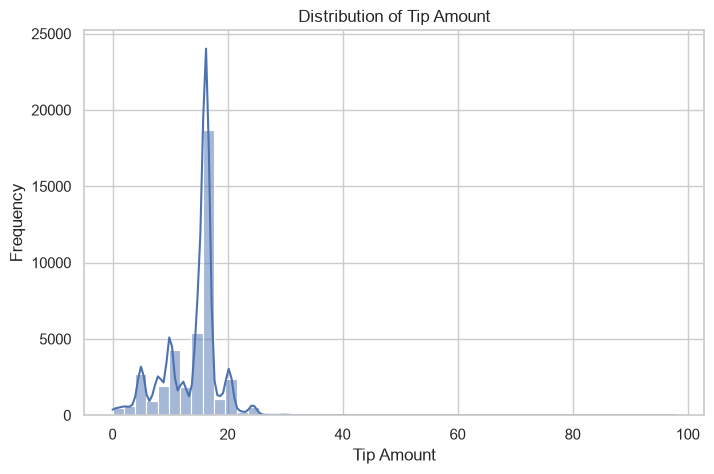

In [3]:
# Load taxi dataset
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
# taxi = pd.read_csv(...)

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
# - taxi.describe()
# - count missing values per column: taxi.isna().sum()

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
taxi = pd.read_csv(TAXI_URL)

# Inspect data
print("Shape:", taxi.shape)

display(taxi.head())

taxi.info()

display(taxi.describe())

# Missing values
print("\nMissing values per column:")
print(taxi.isna().sum())

# Distribution,target
plt.figure(figsize=(8,5))
sns.histplot(taxi["tip_amount"], bins=50, kde=True)
plt.title("Distribution of Tip Amount")
plt.xlabel("Tip Amount")
plt.ylabel("Frequency")
plt.show()

the dataset has: 41,202rows,13columns. 
to explore the dataset I used head(),info(),describe(),shape to understand the shape,structure and quality.
all values in the dataset weren't null. But there were some trips which were unrealistic like the journeys where the distance were zero.the distribution of tip_amount was right skewed. This observation shoes that much more flexible models would perform better than simpler linear models.

In [4]:
# Remve missing values in data
taxi = taxi.dropna()

# Remove invalid rows
taxi = taxi[
    (taxi["trip_distance"] > 0) &
    (taxi["fare_amount"] > 0) &
    (taxi["tip_amount"] >= 0)
]

# Feature engineering
taxi["fare_per_mile"] = taxi["fare_amount"] / taxi["trip_distance"]

taxi["total_surcharge"] = (
    taxi["mta_tax"] +
    taxi["tolls_amount"] +
    taxi["improvement_surcharge"]
)

# decisison categorical columns
taxi = pd.get_dummies(
    taxi,
    columns=[
        "VendorID",
        "RatecodeID",
        "payment_type",
        "store_and_fwd_flag"
    ],
    drop_first=True
)

to handle missing/invalid rows I removed the zero distance trips cause theyre unrealistic, there were no missing values.

I engineered, fare_per_mile,total_surcharge these new features help the model  understand passenger tipping behaviour much better.

I used standardscaler method cause it puts numerical features on a similar scale.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = taxi.drop("tip_amount", axis=1)
y = taxi["tip_amount"]

# Split off test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

# Split remaining data into train (60%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=RANDOM_STATE
)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Validation shape:", X_val_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (24675, 14)
Validation shape: (8225, 14)
Test shape: (8226, 14)


I used a 60/20/20 ratio.
The validation set helps compare and modify models before evaluating the final model on the test set.

The scaler was fitted only on the training data to make sure that information from the validation and test sets dont affect the model during training.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE
)

rf.fit(X_train_scaled, y_train)

def evaluate_model(model, X, y, name):
    preds = model.predict(X)

    rmse = np.sqrt(mean_squared_error(y, preds))
    r2 = r2_score(y, preds)

    print(name)
    print("RMSE:", round(rmse, 3))
    print("R²:", round(r2, 3))
    print()

print("LINEAR REGRESSION")
evaluate_model(lr, X_train_scaled, y_train, "Train")
evaluate_model(lr, X_val_scaled, y_val, "Validation")
evaluate_model(lr, X_test_scaled, y_test, "Test")

print("RANDOM FOREST")
evaluate_model(rf, X_train_scaled, y_train, "Train")
evaluate_model(rf, X_val_scaled, y_val, "Validation")
evaluate_model(rf, X_test_scaled, y_test, "Test")

LINEAR REGRESSION
Train
RMSE: 4.804
R²: 0.051

Validation
RMSE: 5.037
R²: 0.049

Test
RMSE: 5.013
R²: 0.051

RANDOM FOREST
Train
RMSE: 2.836
R²: 0.669

Validation
RMSE: 5.646
R²: -0.195

Test
RMSE: 5.611
R²: -0.189



Random Forest Regressor performed best on the validation training set, I used n_estimators=100,random_state=42.

For Linear Regression, the R² values were very similar across all datasets (Train = 0.051, Validation = 0.049, Test = 0.051), showing consistent performance. For Random Forest, the training R² was 0.669, but the validation and test R² values dropped to -0.195 and -0.189. The training RMSE was also much lower (2.836) than the validation (5.646) and test (5.611) RMSE values.
hence from these results we can come to the conclusion that random forest model is overfitting cause it performs well on only training data but poorly on new data. Regression is more stable.

to reduce the seen overfitting I would reduce the tree depth, I ewould also try and get better features to improve the model. i would increase the minimum samples per leaf, use cross validation techniques to select a better model as well.

Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



Missing values:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Class Distribution:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


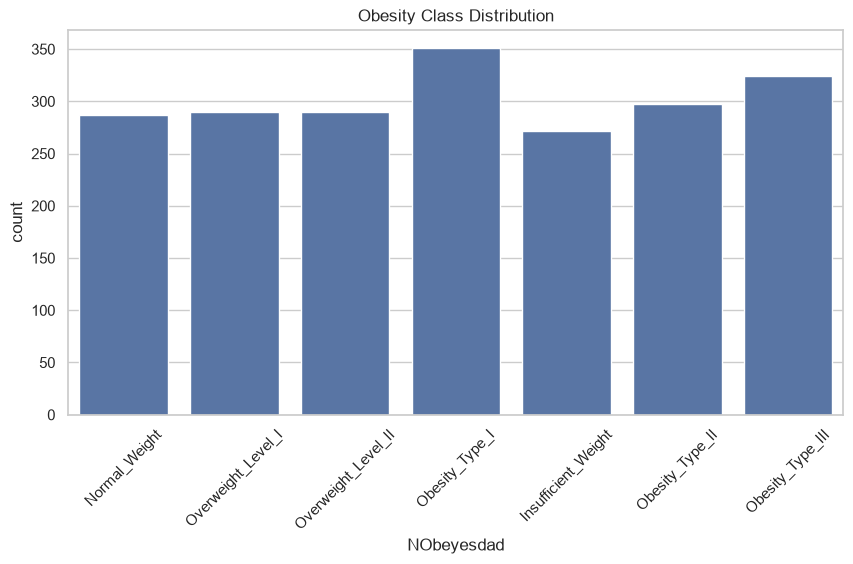

In [7]:

obesity = pd.read_csv(OBESITY_URL)

print("Shape:", obesity.shape)

display(obesity.head())

obesity.info()

display(obesity.describe())

# Missing values
print("\nMissing values:")
print(obesity.isna().sum())

# Class distribution
print("\nClass Distribution:")
print(obesity["NObeyesdad"].value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(data=obesity, x="NObeyesdad")
plt.xticks(rotation=45)
plt.title("Obesity Class Distribution")
plt.show()

The obesity dataset contains 2,111 rows and 17 columns.The Numerical features: Age, Height, Weight, FCVC, NCP, CH2O, FAF, and TUE. Categorical features: Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS, and the target variable NObeyesdad.

Is the target balanced across the 7 classes, and why does class (im)balance matter for classification?

The target classes are  balanced because each obesity category has a similar number of records. Class balance is important and matters for classification cause an imbalanced dataset can cause a model to focus mostly and mainly on larger classes and whiles performing poorly on smaller classes.

In [8]:
from sklearn.preprocessing import LabelEncoder

# BMI feature
obesity["BMI"] = obesity["Weight"] / (obesity["Height"] ** 2)

# Convert yes/no columns to 0/1
binary_cols = [
    "family_history_with_overweight",
    "FAVC",
    "SMOKE",
    "SCC"
]

for col in binary_cols:
    obesity[col] = obesity[col].map({
        "yes": 1,
        "no": 0
    })


obesity = pd.get_dummies(
    obesity,
    columns=[
        "Gender",
        "CAEC",
        "CALC",
        "MTRANS"
    ],
    drop_first=True
)

# Encode target labels
label_encoder = LabelEncoder()

obesity["NObeyesdad_encoded"] = label_encoder.fit_transform(
    obesity["NObeyesdad"]
)

obesity.head()

,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,SMOKE,CH2O,SCC,FAF,TUE,NObeyesdad,BMI,Gender_Male,CAEC_Frequently,CAEC_Sometimes,CAEC_no,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,NObeyesdad_encoded
0,21.0,1.62,64.0,1,0,2.0,3.0,0,2.0,0,0.0,1.0,Normal_Weight,24.386526,False,False,True,False,False,False,True,False,False,True,False,1
1,21.0,1.52,56.0,1,0,3.0,3.0,1,3.0,1,3.0,0.0,Normal_Weight,24.238227,False,False,True,False,False,True,False,False,False,True,False,1
2,23.0,1.80,77.0,1,0,2.0,3.0,0,2.0,0,2.0,1.0,Normal_Weight,23.765432,True,False,True,False,True,False,False,False,False,True,False,1
3,27.0,1.80,87.0,0,0,3.0,3.0,0,2.0,0,2.0,0.0,Overweight_Level_I,26.851852,True,False,True,False,True,False,False,False,False,False,True,5
4,22.0,1.78,89.8,0,0,2.0,1.0,0,2.0,0,0.0,0.0,Overweight_Level_II,28.342381,True,False,True,False,False,True,False,False,False,True,False,6


for the categorical varaibles i converted the yes or no columns into 0 and 1 values, as well as hot encoding for the categorical columns such as gender,CAEC,CALC and MTRANS, i did these to allow machine learning to work with the given data.

yes using weight and height i engineered bmi.yes its fair to use cause it is calculated from existing features and not directly from or using the target label.

for the scalar i chose standardScalar because it would help improve the models performance as it puts the numerical features on a similar scale.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = obesity.drop(
    columns=["NObeyesdad", "NObeyesdad_encoded"]
)

y = obesity["NObeyesdad_encoded"]

# 60/20/20 stratified split
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Validation shape:", X_val_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (1266, 24)
Validation shape: (422, 24)
Test shape: (423, 24)


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = obesity.drop(
    columns=["NObeyesdad", "NObeyesdad_encoded"]
)

y = obesity["NObeyesdad_encoded"]

# Split data
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

Train: (1266, 24)
Validation: (422, 24)
Test: (423, 24)


Student Reasoning — Splitting What split ratio did you choose? Why is stratify=y important for this dataset? What could go wrong if you split without stratifying?
i used 60/20/20 splitting ratio.
stratify is important for this dataset to make sure each dataset contains similar proportions of all 7 obesity classes.
if splitting occurs without stratifying, some classes a lot or very few examples to split which may cause bias and lead to unfair inaccurate evaluation of the model.

Train
Accuracy: 1.0
Macro-F1: 1.0

Validation
Accuracy: 0.990521327014218
Macro-F1: 0.9900351027657371

Test
Accuracy: 0.983451536643026
Macro-F1: 0.9826963686567939



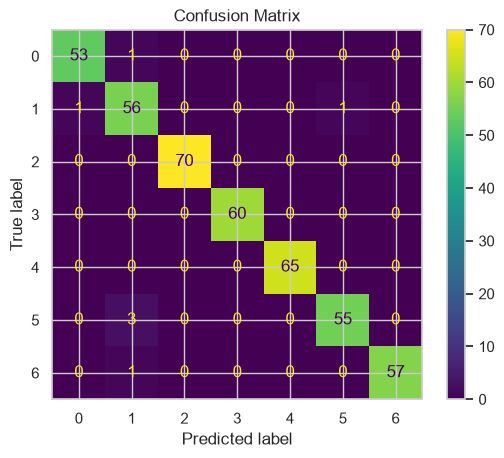

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        54
           1       0.92      0.97      0.94        58
           2       1.00      1.00      1.00        70
           3       1.00      1.00      1.00        60
           4       1.00      1.00      1.00        65
           5       0.98      0.95      0.96        58
           6       1.00      0.98      0.99        58

    accuracy                           0.98       423
   macro avg       0.98      0.98      0.98       423
weighted avg       0.98      0.98      0.98       423



In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

# Train classifier
clf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE
)

clf.fit(X_train_scaled, y_train)

# Evaluate
for name, X_set, y_set in [
    ("Train", X_train_scaled, y_train),
    ("Validation", X_val_scaled, y_val),
    ("Test", X_test_scaled, y_test)
]:

    pred = clf.predict(X_set)

    print(name)
    print("Accuracy:", accuracy_score(y_set, pred))
    print("Macro-F1:", f1_score(y_set, pred, average="macro"))
    print()

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    clf,
    X_test_scaled,
    y_test
)

plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, clf.predict(X_test_scaled)))

i choose the random forest classifier, cause of how well it performs on tabular data, and its ability to easily capture complex relationships for eg between features and obesity.
The model achieved a training accuracy of 1.000 and a training Macro-F1 score of 1.000. The validation accuracy was 0.9905 with a Macro-F1 score of 0.9900, while the test accuracy was 0.9835 with a Macro-F1 score of 0.9827.
the model is overfitting because it perfoms very well on training data the training performance is perfect.

From the confusion matrix, classes with similar obesity levels are more likely to be confused cause they share similar characteristics.

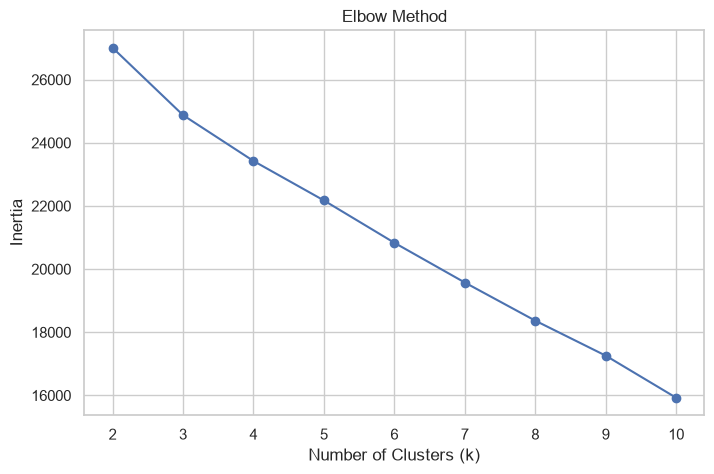

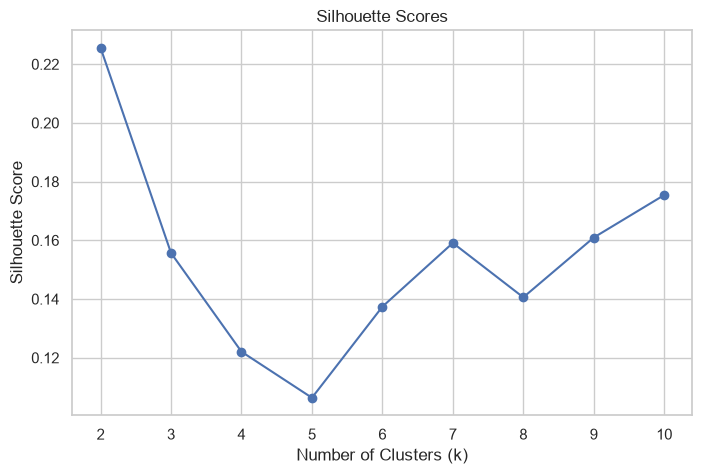

Silhouette Scores:
k=2: 0.226
k=3: 0.156
k=4: 0.122
k=5: 0.106
k=6: 0.137
k=7: 0.159
k=8: 0.141
k=9: 0.161
k=10: 0.175


In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Use only scaled features
X_cluster = X_train_scaled

inertia = []
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = kmeans.fit_predict(X_cluster)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_cluster, labels)
    )

# Elbow Plot
plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Silhouette Plot
plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.show()

print("Silhouette Scores:")
for k, score in zip(range(2,11), silhouette_scores):
    print(f"k={k}: {score:.3f}")

In [13]:
kmeans = KMeans(
    n_clusters=7,
    random_state=RANDOM_STATE,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_cluster)

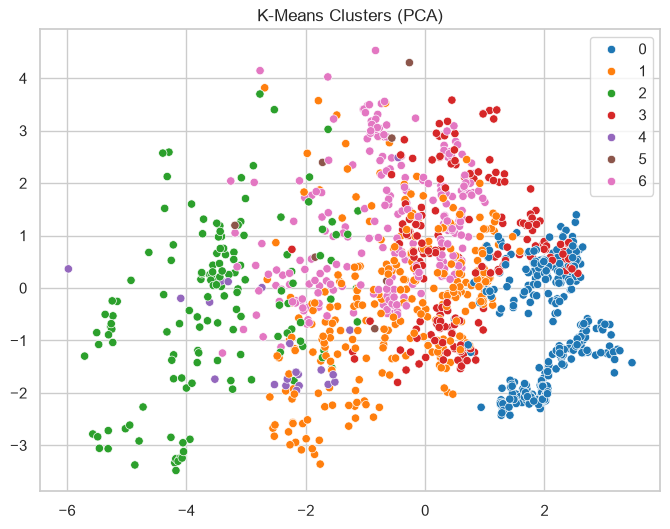

In [14]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=cluster_labels,
    palette="tab10"
)

plt.title("K-Means Clusters (PCA)")
plt.show()

In [15]:
comparison = pd.crosstab(
    cluster_labels,
    y_train
)

print(comparison)

NObeyesdad_encoded   0   1   2   3    4   5   6
row_0                                          
0                    0   0  36  94  194   7  14
1                   58  68  20   0    0  86  59
2                   70  54   1   1    0   8   9
3                    0   3  60  48    0  31  55
4                    3   5   1   0    0  17   1
5                    0   4   2   0    0   0   1
6                   32  38  91  35    0  25  35




I set k=7, since the silhouette score increases once more at k=7 and since there are 7 obesity classes in the data. Moreover, the elbow graph showed that the rate of decline of the inertia becomes gentler at this number of clusters.

There is some correlation between the clusters and actual obesity values, but the clusters do not exactly coincide. Some of the clusters consist mostly of particular obesity classes, whereas some other clusters are mixed up. Thus, K-Means is capable of finding meaningful clusters; however, it is not able to divide the obesity levels in the same way as a supervised algorithm.

In a real world scenario, the clusters may be utilized by some organization to classify people with common health and lifestyle habits in order to run intervention or health program campaigns, even in the absence of the obesity labels.

reflection1

1.The classification algorithm learned from the labeled obesity dataset and could classify obesity correctly. While the K-Means algorithm didn't require any labels to run, it was good at finding natural groupings and structures in the data.

2.Regression produced a numeric prediction (amount of tip) and its performance was measured by RMSE and R². Classification produced categories of obesity and its performance was measured by accuracy, Macro-F1 and confusion matrix.

3.The largest difference between train and test sets occurred in the case of Random Forest regression model. The R² for the training set was 0.669, while for the test set it was -0.189. Such results show that the model is suffering from overfitting. In order to alleviate the problem, the parameters should be tuned.